# ADB: AI for Safer Roads Innovation Challenge
## Data Exploration Notebook

In [1]:
# load libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display

### GeoJSON Files

In [2]:
# Load the files
# CRS - EPSG:4326
ind_gdf = gpd.read_file("../adb_data/ADB_Innovation_Maharashtra.geojson")
thai_gdf = gpd.read_file("../adb_data/ADB_Innovation_Thailand.geojson")     

In [3]:
def geo_eda_compare(gdf1, name1, gdf2, name2):
    df1 = pd.DataFrame({"column": gdf1.columns, "dtype": gdf1.dtypes.values, "null_count": gdf1.isnull().sum().values})
    df2 = pd.DataFrame({"column": gdf2.columns, "dtype": gdf2.dtypes.values, "null_count": gdf2.isnull().sum().values})
    comparison = df1.merge(df2, on="column", how="outer", suffixes=(f"_{name1}", f"_{name2}"))
    print(f"{name1} shape: {gdf1.shape} | {name2} shape: {gdf2.shape}")
    display(comparison)

geo_eda_compare(thai_gdf, "Thailand", ind_gdf, "Maharashtra")

Thailand shape: (55884, 27) | Maharashtra shape: (14082, 28)


,column,dtype_Thailand,null_count_Thailand,dtype_Maharashtra,null_count_Maharashtra
0,AnalysisStatus,str,0.0,str,0.0
1,DISSOLVE_ID,NaN,NaN,str,0.0
2,ExcludeFromSpeedSPI,NaN,NaN,float64,10072.0
3,F85thPercentileSpeed,float64,44340.0,float64,10072.0
4,ForAnalysis,float64,44340.0,NaN,NaN
5,InvPercentile,float64,44340.0,NaN,NaN
6,LandUse,str,44287.0,str,10072.0
7,MedianSpeed,float64,44340.0,float64,10072.0
8,NO_OF_Result_Segments,float64,44340.0,NaN,NaN
9,NumberOverLimit,float64,44340.0,float64,10072.0


In [4]:
# Make sure the required cols have the same name and datatype
ind_gdf = ind_gdf.rename(columns={'Sample_Size_Total':'SampleSizeTotal'})
ind_gdf['SpeedLimit'] = ind_gdf['SpeedLimit'].astype(float)


# Filter the data based on Analysis Status Column
thai_sub_gdf = thai_gdf[(thai_gdf["AnalysisStatus"] == "Valid") & (thai_gdf["SpeedLimit"].notnull())]
india_sub_gdf = ind_gdf[(ind_gdf["AnalysisStatus"] == "Valid") & (ind_gdf["SpeedLimit"].notnull())]

# Columns Selection

# columns unique to each table
thai_cols = ['english_ro', 'ProvinceID']
ind_cols = []

# common columns
required_columns = ['OBJECTID', 'SampleSize_avg', 'WeightedSample', 'SampleSizeTotal',
                     'Percentile', 'RankedPercentile', 'PercentileBand',
                     'SpeedLimit', 'MedianSpeed', 'F85thPercentileSpeed', 
                     'RoadClass', 'LandUse', 'NumberOverLimit', 'PercentOverLimit',
                    'StreetImageLink', 'Shape_Length', 'geometry']

thai_sub_gdf = thai_sub_gdf[thai_cols + required_columns]
india_sub_gdf = india_sub_gdf[ind_cols + required_columns]

In [5]:
# Check the shape
print(f"Thailand dataset dimension: {thai_sub_gdf.shape}.")
print(f"Maharashtra dataset dimension: {india_sub_gdf.shape}.")

print("Not all rows were valid.") 
print(f"Thailand: {round((len(thai_sub_gdf)/len(thai_gdf))*100, 2)}% segments were retained, giving us {len(thai_sub_gdf)} usable segments.")
print(f"Maharashtra: {round((len(india_sub_gdf)/len(ind_gdf))*100, 2)}% segments were retained, giving us {len(india_sub_gdf)} usable segments.")

Thailand dataset dimension: (11544, 19).
Maharashtra dataset dimension: (3577, 17).
Not all rows were valid.
Thailand: 20.66% segments were retained, giving us 11544 usable segments.
Maharashtra: 25.4% segments were retained, giving us 3577 usable segments.


In [6]:
# Check for null values
print(f"Does Thailand subset have any null fields? {thai_sub_gdf.isnull().any().any()}")
print(f"Does Maharashtra subset have any null fields? {india_sub_gdf.isnull().any().any()}")

Does Thailand subset have any null fields? False
Does Maharashtra subset have any null fields? False


## Speed/Road Structure Analysis
- SampleSize_avg:        Average number of GPS probe observations across collection periods
- SampleSizeTotal:       Total raw probe count across all collection periods
- WeightedSample:        Traffic volume proxy (sample size scaled by road length)

- Percentile:            Which traffic volume percentile this road falls into (0-1 scale)
- SpeedLimit:            Posted speed limit from TomTom - not independently validated
- MedianSpeed:           50th percentile of observed vehicle speeds
- F85thPercentileSpeed:  Speed below which 85% of vehicles travel - the traffic engineering standard
- RankedPercentile:      Roads ranked 0-100 by traffic volume for presentation purposes
- PercentileBand:        Categorical traffic band e.g. 0-5%, 5-10%

- NumberOverLimit:       Estimated number of vehicles per year exceeding the speed limit
- PercentOverLimit:      Percentage of vehicles estimated to be exceeding the posted limit
- Shape_Length:          Geometric length of the road segment in map units

- LandUse:               Urban or rural classification based on NASA GRUMP dataset
- RoadClass:             Functional road type - motorway, trunk, primary, or secondary

### Numeric Columns

In [7]:
# Get the distributions of the key numeric columns
def key_summary_num(gdf, country_name):
    # Summary table
    rows = []
    numeric_cols = []
    
    for col in required_columns:          # iterates over required_columns instead of speed_cols
        if col in gdf.columns and gdf[col].dtype in ["float64", "int64"]:
            numeric_cols.append(col)
            rows.append({
                "column": col,
                "min": gdf[col].min(),
                "max": gdf[col].max(),
                "mean": gdf[col].mean().round(2),
                "range": gdf[col].max() - gdf[col].min()
            })
    
    display(pd.DataFrame(rows))
    
    # Histograms for each numeric column
    n_cols = 3
    n_rows = -(-len(numeric_cols) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        axes[i].hist(gdf[col].dropna(), bins=30, color='steelblue', edgecolor='white')
        axes[i].set_title(col)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Count')
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'{country_name} - Distribution of Numeric Columns', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


,column,min,max,mean,range
0,SampleSize_avg,3.333333,9.031018e+07,669755.97,9.031018e+07
1,WeightedSample,0.000000,1.551703e+09,4538416.07,1.551703e+09
2,SampleSizeTotal,8.000000,9.031018e+07,762447.35,9.031018e+07
3,Percentile,0.000000,1.000000e+00,0.04,1.000000e+00
4,RankedPercentile,0.008645,9.979253e+01,49.90,9.978389e+01
5,SpeedLimit,0.000000,1.200000e+02,80.55,1.200000e+02
6,MedianSpeed,0.000000,1.300000e+02,64.54,1.300000e+02
7,F85thPercentileSpeed,0.000000,1.500000e+02,78.28,1.500000e+02
8,NumberOverLimit,0.000000,5.893935e+07,211431.05,5.893935e+07
9,PercentOverLimit,0.000000,1.000000e+00,0.22,1.000000e+00


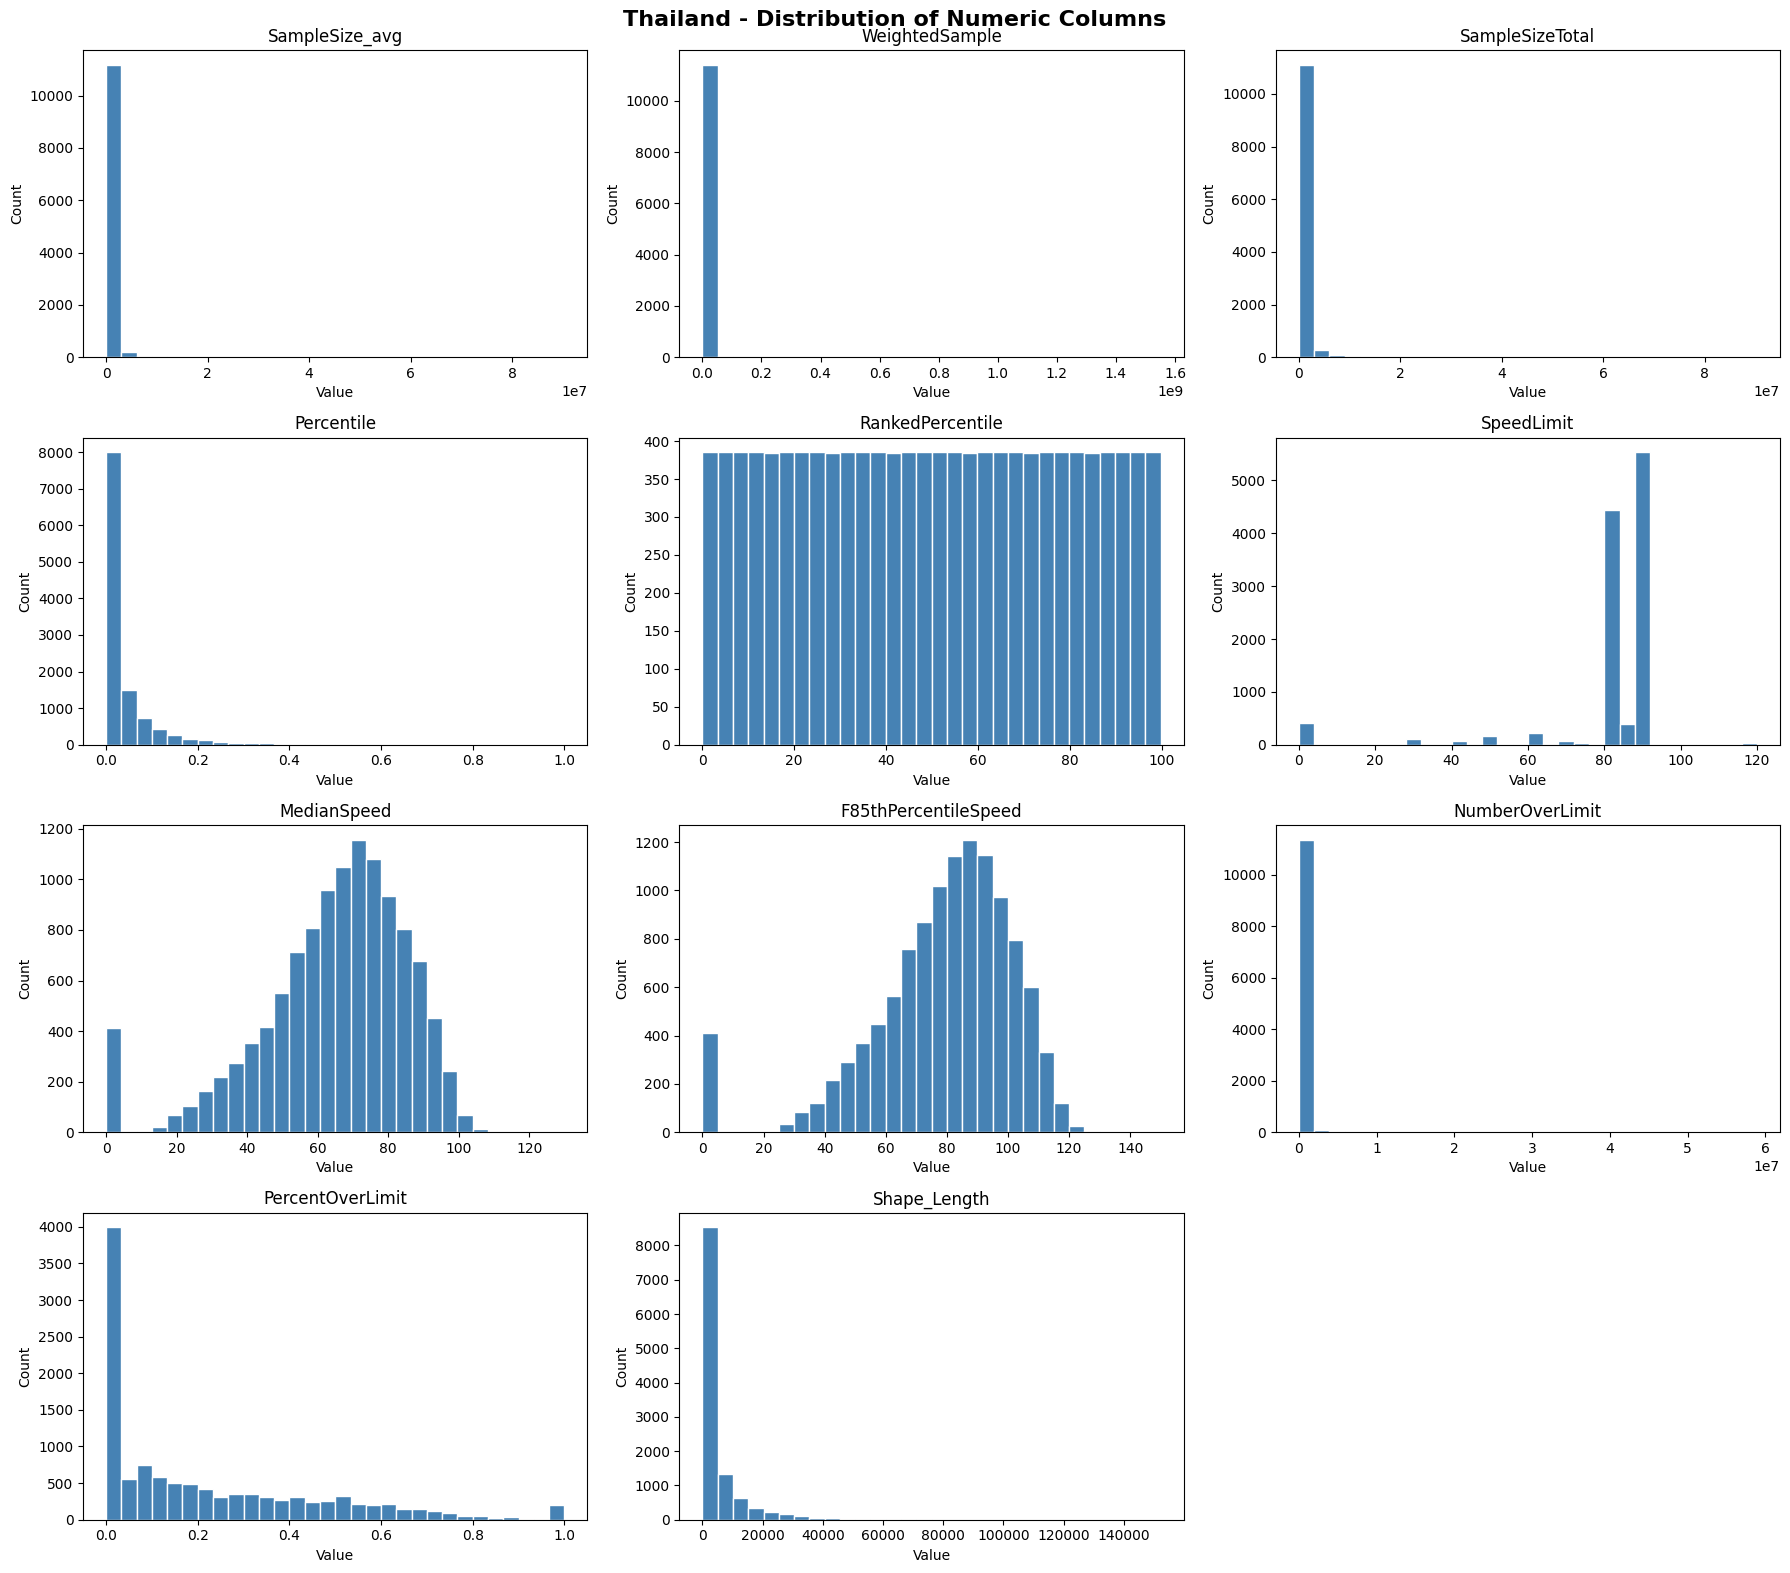

In [8]:
key_summary_num(thai_sub_gdf, 'Thailand')

Based on the above table/chart, there are some roads in Thailand have zero speed. We remove them from the working dataset below. 
Despite knowing that TomTom speed data has not been validated, the question remains: why do those rows exist? 

,column,min,max,mean,range
0,SampleSize_avg,5.000000e-01,4.894736e+06,85586.79,4.894735e+06
1,WeightedSample,2.950476e+00,2.602851e+07,363677.17,2.602851e+07
2,SampleSizeTotal,1.000000e+00,5.798907e+07,411820.68,5.798906e+07
3,Percentile,1.704414e-09,1.000000e+00,0.06,1.000000e+00
4,RankedPercentile,4.987531e-04,1.000000e+00,0.48,9.995012e-01
5,SpeedLimit,2.000000e+01,8.000000e+01,52.78,6.000000e+01
6,MedianSpeed,1.200000e+01,9.666667e+01,44.66,8.466667e+01
7,F85thPercentileSpeed,1.333333e+01,1.146667e+02,56.37,1.013333e+02
8,NumberOverLimit,0.000000e+00,5.196662e+07,174503.58,5.196662e+07
9,PercentOverLimit,0.000000e+00,1.000000e+00,0.28,1.000000e+00


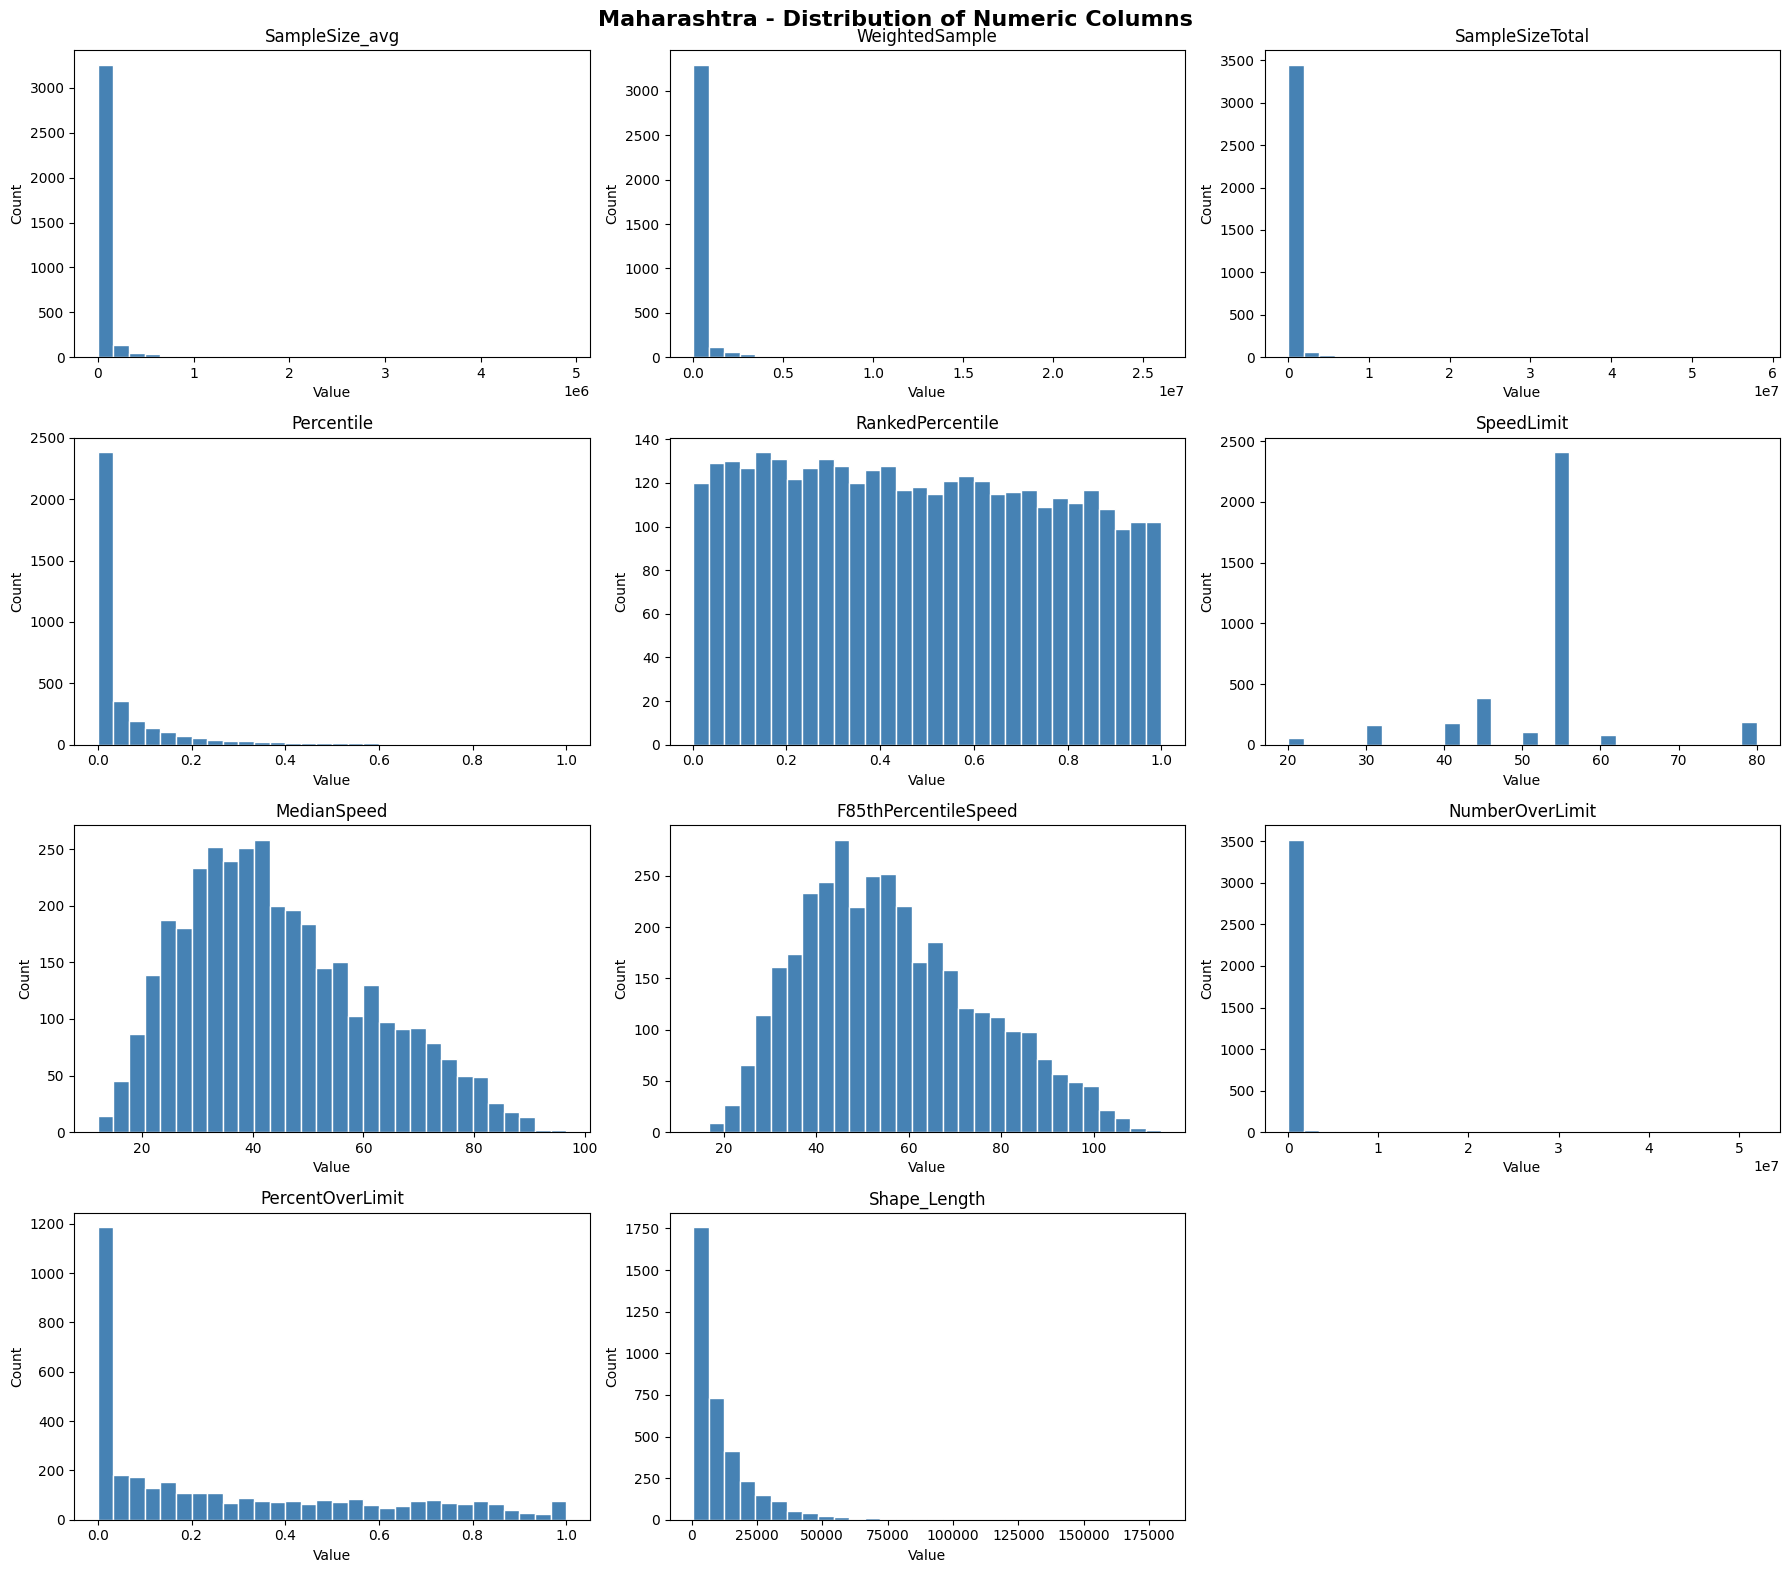

In [9]:
key_summary_num(india_sub_gdf, 'Maharashtra')

#### Thailand Roads with 0 Speed Limit

In [10]:
zero_limit = thai_sub_gdf[thai_sub_gdf["SpeedLimit"] == 0]
print(f"Proportion of roads with zero speed limit: {round((zero_limit.shape[0]/thai_sub_gdf.shape[0])*100, 2)}% ({zero_limit.shape[0]}/{thai_sub_gdf.shape[0]})")

# The roads which have zero speed limit - do they traffic? If yes then data error
# Summarize: how many of the zero-limit roads actually have traffic?
print(f"Zero speed limit roads WITH traffic data: {len(zero_limit[zero_limit['SampleSizeTotal'] > 0])}")
print(f"Zero speed limit roads WITHOUT traffic data: {len(zero_limit) - len(zero_limit[zero_limit['SampleSizeTotal'] > 0])}")

Proportion of roads with zero speed limit: 3.55% (410/11544)
Zero speed limit roads WITH traffic data: 410
Zero speed limit roads WITHOUT traffic data: 0


In [11]:
# Exclude zero speed limit roads
# Zero values likely reflect missing TomTom coverage, not actual road conditions
thai_sub_gdf = thai_sub_gdf[thai_sub_gdf["SpeedLimit"] > 0]

### Categorical Columns

In [12]:
# Categorical columns: RoadClass, LandUse and PercentileBand
def key_summary_cat(gdf):
    rows = []
    skip_cols = ['StreetImageLink', 'geometry']


    for col in required_columns:
        if col in skip_cols:
            continue
        if gdf[col].dtype == "str":
            rows.append({
                "column": col,
                "unique_values": gdf[col].nunique(),
                "unique_list": gdf[col].unique().tolist(),
                "mode": gdf[col].mode()[0],
                "mode_count": gdf[col].value_counts().iloc[0],
                "mode_proportion": (gdf[col].value_counts().iloc[0] / len(gdf)).round(3)
            })
    return pd.DataFrame(rows)

In [13]:
# THAILAND
display(key_summary_cat(thai_sub_gdf))

,column,unique_values,unique_list,mode,mode_count,mode_proportion
0,PercentileBand,20,"[0-5%, 5-10%, 25-30%, 35-40%, 55-60%, 20-25%, ...",0-5%,8542,0.767
1,RoadClass,4,"[primary, secondary, motorway, trunk]",secondary,5840,0.525
2,LandUse,2,"[RURAL, URBAN]",URBAN,5593,0.502


In [14]:
# MAHARASHTRA
display(key_summary_cat(india_sub_gdf))

,column,unique_values,unique_list,mode,mode_count,mode_proportion
0,PercentileBand,20,"[0-5%, 5-10%, 10-15%, 15-20%, 20-25%, 25-30%, ...",0-5%,2591,0.724
1,RoadClass,4,"[secondary, primary, trunk, motorway]",secondary,1366,0.382
2,LandUse,2,"[RURAL, URBAN]",RURAL,2816,0.787


## Intermediate Analysis (Thailand Only)

In [15]:
# What is the count of each Road Class in Rural vs Urban Land Use
thai_sub_gdf.groupby(["LandUse", "RoadClass"]).size().unstack(fill_value=0)

RoadClass,motorway,primary,secondary,trunk
LandUse,,,,
RURAL,18,1377,3076,1070
URBAN,111,1779,2764,939


#### Road Classification Hierarchy
##### Assumptions made
- Motorway: The highest classification. Fully controlled-access highways (like expressways or intercity freeways). High speed, no intersections, no pedestrians. Think of Thailand's expressways connecting major cities.
- Trunk: Major arterial roads that connect cities and regions, but not fully controlled-access. May have traffic lights, junctions, or at-grade crossings. Still high capacity and speed.
- Primary: mportant roads within or between urban areas. Main city roads, national highways running through towns. Lower speed than trunk, more intersections, more mixed traffic.
- Secondary: Smaller connecting roads, district roads, local arterials. Moderate traffic, lower speeds, more pedestrians and side streets.

In [16]:
# Traffic volume on Rural vs Urban - which one has more vehicle?
thai_sub_gdf.groupby("LandUse")[["SampleSizeTotal", "WeightedSample"]].agg(["mean", "median", "sum"])

SampleSizeTotal                         WeightedSample            \
                   mean    median           sum           mean    median   
LandUse                                                                    
RURAL      4.101296e+05  171738.0  2.272528e+09   2.819935e+06  326726.4   
URBAN      1.143672e+06  279565.0  6.396555e+09   6.522748e+06  302705.0   

                       
                  sum  
LandUse                
RURAL    1.562526e+10  
URBAN    3.648173e+10

Urban roads have ~2.8x more raw observations (mean SampleSizeTotal: 1.14M vs 410K) more vehicles on urban roads means more GPS probes captured. But the median gap is much smaller (277K vs 174K) - meaning the typical rural and urban road are not as different as the means suggest. The large mean gap is being driven by a few very busy urban roads pulling the average up.

WeightedSample amplifies this further, urban mean is ~6.5M vs rural ~2.8M, more than doubling. This reflects that urban roads carry disproportionately more traffic when weighted properly based on road length.

In [17]:
# How do speed values relate to the kind of road? Check the mode speed values for each road class?
# Note: There are 40 different speed values
thai_sub_gdf.groupby("RoadClass")[["SpeedLimit", "MedianSpeed"]].agg(["min", "mean", "max"])

SpeedLimit                   MedianSpeed                  
                 min       mean    max         min       mean    max
RoadClass                                                           
motorway        20.0  85.573643  120.0     26.3125  75.583794  103.8
primary         20.0  82.717681  100.0      2.5000  70.152736  104.0
secondary       20.0  83.448116   90.0      9.3500  60.291143   96.0
trunk           30.0  84.839223  120.0     12.9000  80.543510  130.0

In [18]:
# There are some motorways that have 20km/h - how many?
print(len(thai_sub_gdf[(thai_sub_gdf["SpeedLimit"] == 20) & (thai_sub_gdf["RoadClass"] == 'motorway')]))

# Since there are only 2, these roads can be ignored and interpreted as data error since the TomTom data is not validated.

2


## Save the dataset as GeoJSON and CSV

In [ ]:
# Save as GeoJSON (preserves geometry)
thai_sub_gdf.to_file('data/thai_clean_gdf.geojson', driver='GeoJSON')
india_sub_gdf.to_file('data/india_clean_gdf.geojson', driver='GeoJSON')

# Save as CSV (tabular)
thai_sub_gdf.to_csv('data/thai_clean_gdf.csv', index=False)
india_sub_gdf.to_csv('data/india_clean_gdf.csv', index=False)